In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model
from sklearn.utils.class_weight import compute_class_weight
import os

I0000 00:00:1783439426.359248   92497 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783439426.685495   92497 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783439427.808667   92497 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
image_generator = ImageDataGenerator(
    rescale=1.0 / 255.0,
    shear_range=0.1,
    zoom_range=0.3
)
image_generator_test = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [3]:
datasetTrain = os.path.join('datasets', 'XRay', 'Train')
datasetTest = os.path.join('datasets', 'XRay', 'Test')

In [4]:
train_data = image_generator.flow_from_directory(
    datasetTrain,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=16
)

Found 600 images belonging to 2 classes.


In [5]:
test_data = image_generator.flow_from_directory(
    datasetTest,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=16
)

Found 150 images belonging to 2 classes.


In [6]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/docroch/Projects/learning-data-science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783439429.549124   92497 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [7]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

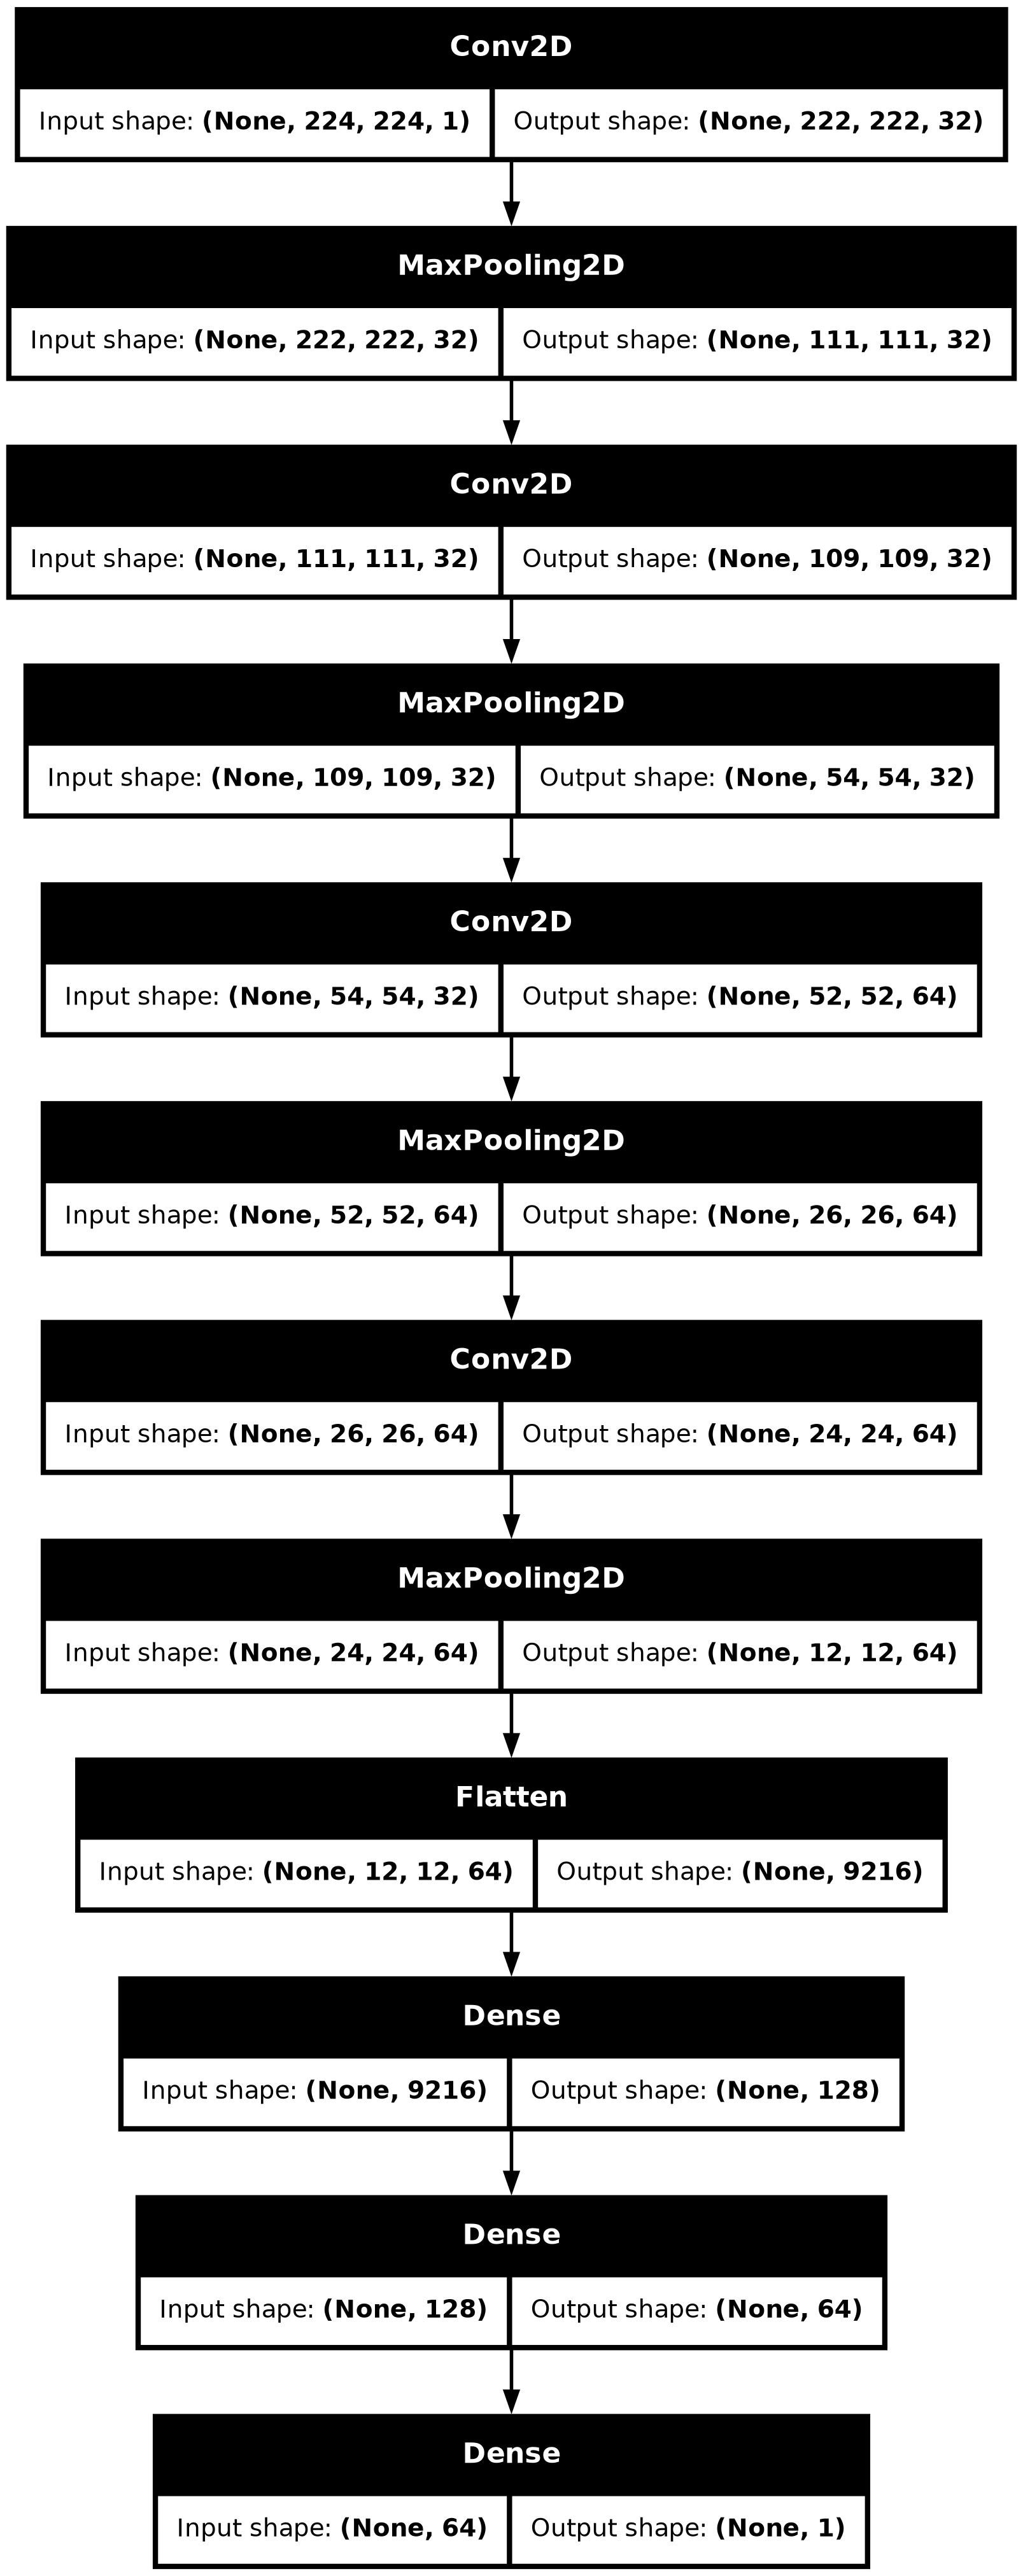

In [8]:
plot_model(model, show_shapes=True, show_layer_names=False)

In [9]:
train_data.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [10]:
compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

array([1.5 , 0.75])

In [11]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

In [12]:
class_weights = dict(zip(np.unique(train_data.classes), weights))

In [13]:
class_weights

{np.int32(0): np.float64(1.5), np.int32(1): np.float64(0.75)}

In [14]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=3)
rlrop = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2, min_lr=0.001)

In [15]:
mch = ModelCheckpoint('cnnxray.h5', monitor='val_loss', mode='min', save_best_only=True)

In [16]:
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=30,
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[es, rlrop, mch],
    class_weight=class_weights
)

Epoch 1/30


I0000 00:00:1783439430.837426   92497 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783439431.939395   92867 service.cc:153] XLA service 0x7832f8037e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783439431.939415   92867 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783439431.975269   92867 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783439432.257869   92867 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783439432.271610   92867 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2629__.45


 1/38 ━━━━━━━━━━━━━━━━━━━━ 5:13 8s/step - accuracy: 0.6250 - loss: 0.7150

I0000 00:00:1783439439.265593   92867 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1783439439.736335   92860 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2629__.45


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.5300 - loss: 0.6738

...

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.7750 - loss: 0.4954 - val_accuracy: 0.7533 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8600 - loss: 0.3477

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8600 - loss: 0.3477 - val_accuracy: 0.7867 - val_loss: 0.4393 - learning_rate: 0.0010
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.8883 - loss: 0.2956 - val_accuracy: 0.8067 - val_loss: 0.5694 - learning_rate: 0.0010
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8967 - loss: 0.2644 - val_accuracy: 0.7867 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8900 - loss: 0.2763

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.8900 - loss: 0.2763 - val_accuracy: 0.8000 - val_loss: 0.3982 - learning_rate: 0.0010
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9167 - loss: 0.1858

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9167 - loss: 0.1858 - val_accuracy: 0.8267 - val_loss: 0.3971 - learning_rate: 0.0010
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9117 - loss: 0.2082

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9117 - loss: 0.2082 - val_accuracy: 0.9067 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9300 - loss: 0.2029 - val_accuracy: 0.8200 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9483 - loss: 0.1414 - val_accuracy: 0.8333 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9350 - loss: 0.1803 - val_accuracy: 0.8467 - val_loss: 0.3371 - learning_rate: 0.0010


In [20]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

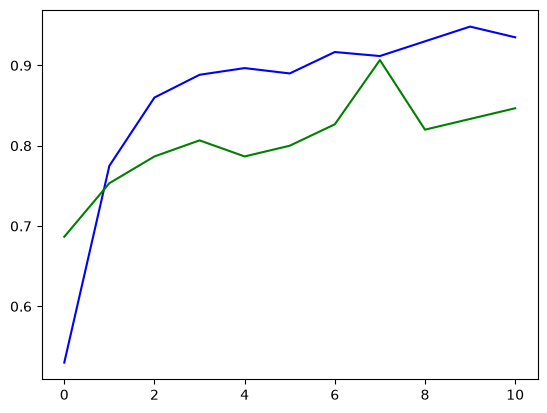

In [21]:
plt.plot(history.history['accuracy'], color='blue')
plt.plot(history.history['val_accuracy'], color='green')

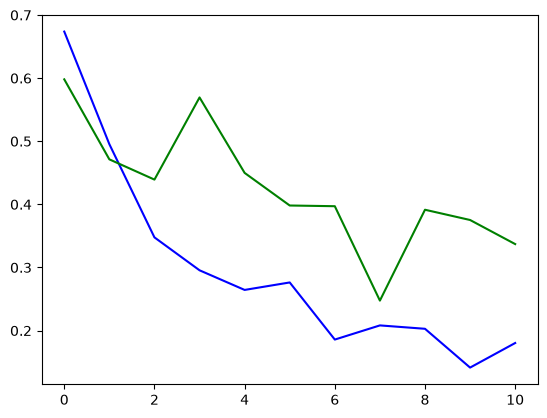

In [22]:
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='green')